# PROJETO UNIDADE 1 - REDES NEURAIS

## Importando as bibliotecas

In [118]:
# Importando as bibliotecas que serão utilizadas

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Carregando o dataset: Global AI & Data Jobs Salary Dataset

- fonte: https://www.kaggle.com/datasets/mohankrishnathalla/global-ai-and-data-jobs-salary-dataset

In [119]:
# importando o dataset
import kagglehub

path = kagglehub.dataset_download("mohankrishnathalla/global-ai-and-data-jobs-salary-dataset")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'global-ai-and-data-jobs-salary-dataset' dataset.
Path to dataset files: /kaggle/input/global-ai-and-data-jobs-salary-dataset


In [120]:
dataframe = pd.read_csv("/kaggle/input/global-ai-and-data-jobs-salary-dataset/global_ai_jobs.csv")
# criando uma cópia necessária para alterações dos dados
df = dataframe.copy()

In [121]:
# este será o dataframe que será trabalhado
df

,id,country,job_role,ai_specialization,experience_level,experience_years,salary_usd,bonus_usd,education_required,industry,...,vacation_days,skill_demand_score,automation_risk,job_security_score,career_growth_score,work_life_balance_score,promotion_speed,salary_percentile,cost_of_living_index,employee_satisfaction
0,1,UAE,Machine Learning Engineer,Reinforcement Learning,Entry,0,66465,5395,Master,Automotive,...,27,12,76,57,65,73,15,55,1.23,76
1,2,USA,AI Engineer,LLM,Entry,1,75507,11713,Bootcamp,Retail,...,27,54,29,69,60,51,15,58,0.87,67
2,3,Brazil,Research Scientist,Analytics,Entry,0,41660,5268,PhD,Healthcare,...,13,12,49,70,59,68,37,13,2.13,61
3,4,India,Software Engineer AI,Computer Vision,Senior,6,43268,7975,Diploma,Tech,...,30,80,47,79,65,55,46,74,1.49,56
4,5,Germany,Machine Learning Engineer,Computer Vision,Entry,0,69119,4758,Master,Retail,...,24,82,47,64,52,69,17,21,0.87,72
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89995,89996,Germany,Research Scientist,Forecasting,Lead,14,147903,30957,Bootcamp,Energy,...,27,4,71,85,56,77,14,17,2.46,85
89996,89997,Germany,Machine Learning Engineer,NLP,Mid,2,81608,7991,Bootcamp,Gaming,...,19,46,65,71,34,62,61,88,1.38,68
89997,89998,Singapore,Computer Vision Engineer,Computer Vision,Mid,5,91473,17876,Bootcamp,Energy,...,27,89,6,72,75,77,12,28,2.14,71
89998,89999,Germany,AI Engineer,MLOps,Mid,4,91343,13147,Bachelor,Education,...,17,83,66,77,66,62,36,36,1.78,72


In [122]:
# visualização geral do dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       90000 non-null  int64  
 1   country                  90000 non-null  object 
 2   job_role                 90000 non-null  object 
 3   ai_specialization        90000 non-null  object 
 4   experience_level         90000 non-null  object 
 5   experience_years         90000 non-null  int64  
 6   salary_usd               90000 non-null  int64  
 7   bonus_usd                90000 non-null  int64  
 8   education_required       90000 non-null  object 
 9   industry                 90000 non-null  object 
 10  company_size             90000 non-null  object 
 11  interview_rounds         90000 non-null  int64  
 12  year                     90000 non-null  int64  
 13  work_mode                90000 non-null  object 
 14  weekly_hours          

### Definindo as colunas Target

Antes de adentrarmos para a fase 1, precisaremos definir as colunas *targets* da nossa aplicação, as quais servirão como rótulos para implementar o nosso modelo de aprendizagem supervisionada.

O objetivo é fazer um simulador baseado em rede neural que, dado o perfil de um profissional, prevê o pacote de oferta que o mercado tenderia a oferecer: salário em USD, proporção de trabalho remoto e porte da empresa. Um cientista de dados sênior no Brasil, por exemplo, poderia consultar o modelo e receber algo como "espere USD 95k, 50% remoto, empresa de médio porte". Tal informação é diretamente acionável para negociações e decisões de carreira.


As que foram escolhidas para o projeto serão justamente o que a rede vai entregar na saída, que são:

- `real_salary_usd` = `salary_usd` + `bonus_usd`: Salário real predito
- `work_mode`: Modalidade do trabalho predita
- `company_size`: Tamanho da empresa predito

In [123]:
# criando a nova coluna
df['real_salary_usd'] = df['salary_usd'] + df['bonus_usd']
# deletando as antigas
df = df.drop(columns=['salary_usd', 'bonus_usd'])
# exibindo o target
df['real_salary_usd'].value_counts()

,count
real_salary_usd,
81135,6
69870,6
91135,6
74131,6
93639,6
...,...
209379,1
82970,1
41676,1


In [124]:
df['work_mode'].value_counts()

,count
work_mode,
Onsite,30233
Remote,30005
Hybrid,29762


In [125]:
df['company_size'].value_counts()

,count
company_size,
Medium,18328
Startup,18008
Enterprise,17988
Small,17919
Large,17757


## FASE 1 - PRÉ-PROCESSAMENTO DOS DADOS

### Tratamento de Dados: Visão Geral

Estes são as principais tarefas da etapa de préprocessamento de dados:

- Remover Colunas Irrelevantes
- Verificar Dados Faltantes
- Encoding de Colunas Categoricas
- Padronização dos dados
- *Splitar* os dados
- *Feature Selection*


### Tratamento de Dados: Removendo Colunas Irrelevantes

Dentro do dataset que será utilizado para treinar a rede neural artificial, será necessário eliminar as colunas que não agregarão valor preditivo para as fases de treinamento, teste e validação do nosso modelo. Dessa forma, conseguiremos "enxugar" as *features* (i.e. atributos) do nosso modelo.

As colunas que irei remover do dataset serão:

- `id`: indica apenas o índice do registro, logo, não possui valor preditivo para o modelo.

In [126]:
# Criando uma lista com os nomes das colunas que eu considero como irrelevantes (features irrelevantes)
drop = ['id']
df.drop(columns=drop, inplace= True)

In [127]:
# Conferindo os valores após o drop das colunas
df.columns.values

array(['country', 'job_role', 'ai_specialization', 'experience_level',
       'experience_years', 'education_required', 'industry',
       'company_size', 'interview_rounds', 'year', 'work_mode',
       'weekly_hours', 'company_rating', 'job_openings',
       'hiring_difficulty_score', 'layoff_risk', 'ai_adoption_score',
       'company_funding_billion', 'economic_index', 'ai_maturity_years',
       'offer_acceptance_rate', 'tax_rate_percent', 'vacation_days',
       'skill_demand_score', 'automation_risk', 'job_security_score',
       'career_growth_score', 'work_life_balance_score',
       'promotion_speed', 'salary_percentile', 'cost_of_living_index',
       'employee_satisfaction', 'real_salary_usd'], dtype=object)

### Tratamento de Dados: Verificando Dados Faltantes

Precisamos verificar primeiramentes se existem dados faltantes no dataset. Caso existam, será necessário adotar alguma estratégia para poder lidar com eles. As geralmente mais utilizadas são essas listadas abaixo:

**Estratégias:**

1.   **Remoção das colunas**: Solução menos recomendada. Somente deverá ser utilizada quando a variável não exercer influência no resultado procurado.
2.   **Remoção das linhas**: Solução melhor, porém ainda não é a ideal para um dataset com poucos exemplos.
3.   **Preenchimento com um valor definido**: Pode-se preencher os dados faltantes com o valor que melhor convier para o problema. Para ser usado adequadamente, precisa-se saber que valor é esse.
4.   **Preenchimento com a média ou moda**: Solução mais adequada na maioria dos casos.

Mas antes de tudo, iremos verificar a existência de dados faltantes no dataset escolhido, logo abaixo:

Como não temos dados faltantes para serem tratados, pularemos para a próxima etapa de tratamento.

In [128]:
# Verificando as colunas que possuem dados vazios
hasNan = df.isna().sum()
print(hasNan)

country                    0
job_role                   0
ai_specialization          0
experience_level           0
experience_years           0
education_required         0
industry                   0
company_size               0
interview_rounds           0
year                       0
work_mode                  0
weekly_hours               0
company_rating             0
job_openings               0
hiring_difficulty_score    0
layoff_risk                0
ai_adoption_score          0
company_funding_billion    0
economic_index             0
ai_maturity_years          0
offer_acceptance_rate      0
tax_rate_percent           0
vacation_days              0
skill_demand_score         0
automation_risk            0
job_security_score         0
career_growth_score        0
work_life_balance_score    0
promotion_speed            0
salary_percentile          0
cost_of_living_index       0
employee_satisfaction      0
real_salary_usd            0
dtype: int64


### Tratamento de Dados: Estrutura de *bloxplot*

Ao utilizar o bloxplot, podemos ver como está a distribuição dos nossos dados por todo o conjunto. A partir disso, podemos detectar problemas à serem tratados: identificar outliers, padronizar a escala, dentre outras coisas.

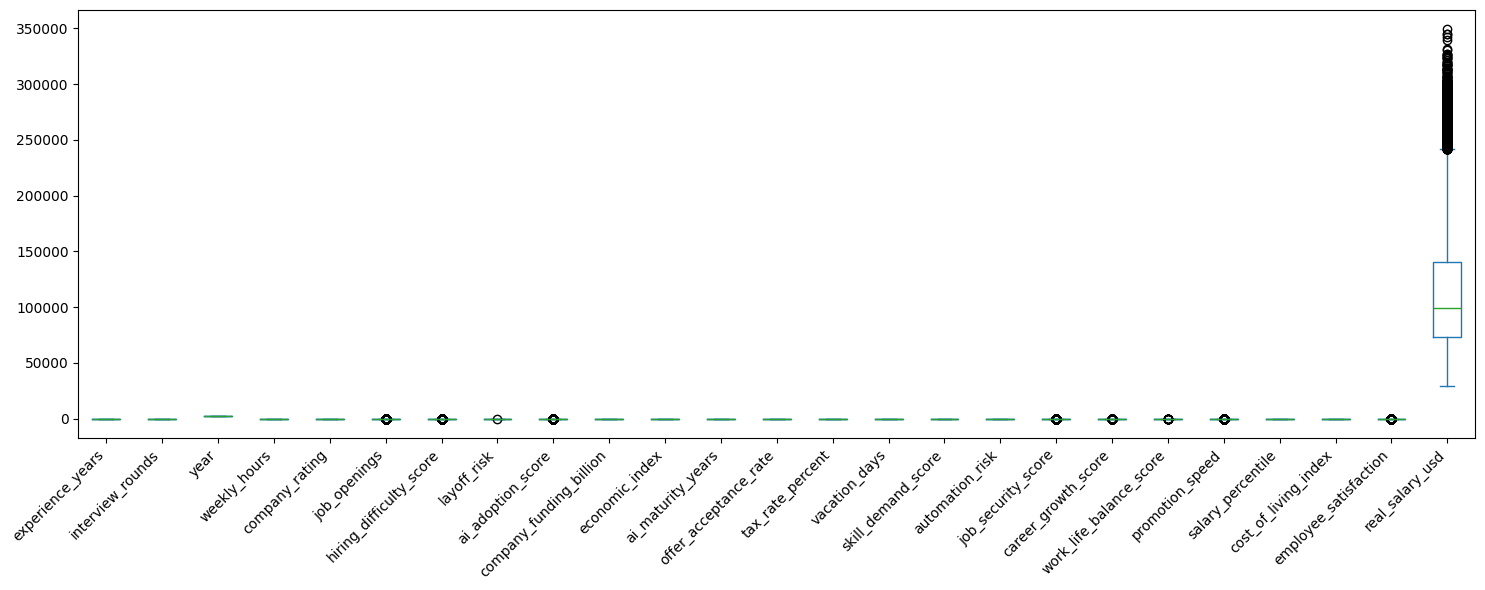

In [129]:
ax = df.plot(kind='box', figsize=(15, 6))
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

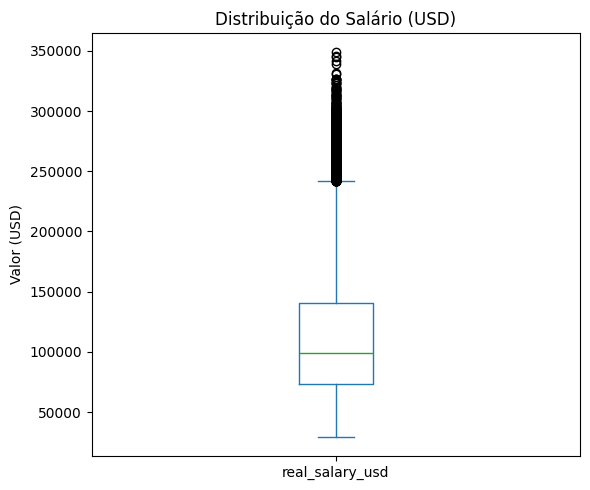

In [130]:
# Boxplot das amostras de real_salary_USD

df[['real_salary_usd']].plot(kind='box', figsize=(6, 5))
plt.title('Distribuição do Salário (USD)')
plt.ylabel('Valor (USD)')
plt.tight_layout()
plt.show()

### Tratamento de Dados: Eliminando os Outliers

Em algumas colunas do dataset, como em `real_salary_usd`, haverão valores discrepantes que impactarão negativamente para a análises dos dados que o modelo fará para a predição. Isso acontece por conta da má distribuição dos dados, contudo, a fim de evitar este cenário:

1. Os *outliers* serão detectados por meio do plot do *boxplot*. Esse diagrama de blocos será plotado para os atributos que foram selecionados do dataset para a construção do modelo. O objetivo é verificar por meio desta ferramenta, a existência de *outliers*.

2. Com a detecção dos *outliers* existentes nos atributos, o método que será utilizado para a remoção deles será **a regrado 1.5 * IQR** (Variação Interquartil).

**CONTUDO...** perceba a quantidade dos *outliers* representa uma boa parcela de amostras da distribuição salarial. Se tratarmos os *outliers* estaremos eliminando uma quantidade considerável de amostras que serão utilizadas para o treinamento do modelo.

In [131]:
# iterando cada coluna das colunas de números do bloxplot para tratar os outliers
#colunas_numericas = df.select_dtypes(include=['int64', 'float64']).columns

#for coluna in colunas_numericas:
#    # cálculos dos quartis
#    q1 = df[coluna].quantile(0.25)
#    q3 = df[coluna].quantile(0.75)
#    # iqr
#   iqr = q3 - q1
    # limites inferior e superior
#   lLim = q1 - 1.5 * iqr
#   hLim = q3 + 1.5 * iqr

    # aplicando a substituição dos valores
#   df.loc[df[coluna] < lLim, coluna] = lLim
#   df.loc[df[coluna] > hLim, coluna] = hLim

#df[colunas_numericas].plot(kind='box', figsize=(15, 6))
#plt.title("Boxplot após Tratamento de Outliers", fontsize=14)
#plt.xticks(rotation=90)
#plt.show()

### Tratamento de Dados: *Encoding* de Colunas Categóricas

Exitem muitas colunas que serão utilizadas para a construção do modelo. Como a rede neural MLP sempre trabalha com números, devemos converter as colunas as quais são preenchidas com *strings*. A questão é que existem colunas categóricas que possuem ordem/hierarquia e outras que não tem. E é por isso que utilizo dois *encoders*:

- **Label Encoding**: Para realizar o *encoding* de colunas que possuem ordem [ALFABÉTICA].Portanto, a ordem precisa ser respectivamente, por exemplo: *Abacaxi (0), Banana (1) < Maçã (2) < Laranja (3)*.

- **One-Hot Encoding**: Para realizar o *encoding* de colunas que não possuem ordem. Por exemplo: `country` não tem hierarquia... tanto faz a ordem que foi escolhido para o encoding.

Obs: dá pra usar `.map()` para definir manualmente a ordem.

In [132]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

# LABEL ENCODING
#coluna: experience_level
ordem_exp = ['Entry', 'Mid', 'Senior', 'Lead']
df['experience_level'] = df['experience_level'].map(
    {v: i for i, v in enumerate(ordem_exp)}
)
#coluna: education_required
ordem_edu = ['Bootcamp', 'Diploma', 'Bachelor', 'Master', 'PhD']
df['education_required'] = df['education_required'].map(
    {v: i for i, v in enumerate(ordem_edu)}
)
#coluna: company_size (target)
ordem_comp = ['Startup', 'Small', 'Medium', 'Large', 'Enterprise']
df['company_size'] = df['company_size'].map(
    {v: i for i, v in enumerate(ordem_comp)}
)
#coluna: work_mode (target). sem ordem real, dá pra usar label encoding ou one-hot
le.fit(['Onsite', 'Hybrid', 'Remote'])
df['work_mode'] = le.transform(df['work_mode'])

#ONE HOT ENCODING
df = pd.get_dummies(df, columns=['country', 'job_role', 'ai_specialization', 'industry'], dtype= int)

# Verificando o resultado
print(df.shape)   # vai aumentar o número de colunas (cada categoria vira uma coluna)
print(df.dtypes)  # todas devem ser numéricas agora

(90000, 67)
experience_level       int64
experience_years       int64
education_required     int64
company_size           int64
interview_rounds       int64
                       ...  
industry_Gaming        int64
industry_Healthcare    int64
industry_Retail        int64
industry_Tech          int64
industry_Telecom       int64
Length: 67, dtype: object


### Tratamento de Dados: Dividindo o Conjunto de Dados

**Separação de features e labels**

Como já mencionado lá no começo, os targets para os rótulos serão:

- `real_salary_usd` (`y_salary`)
- `work_mode` (`y_workmode`)
- `company_size` (`y_company`)

As *features* serão as colunas remanescentes que foram filtradas ao longo da fase de pré-processamento dos dados.

**Split do conjunto de dados**

Além da separação das features e labels, o conjunto de dados será divido em uma proporção 80/20, respectivamente, para treino e teste. Portanto:

1. O conjunto de entradas `X` será dividido entre conjuntos de treino e de teste (`X_train` `X_test`, respectivamente).

2. O conjunto das labels de saída será divido da seguinte forma:

- `y_salary`: `y_salary_train`, `y_salary_test`
- `y_work_mode`: `y_workmode_train`, `y_workmode_test`
- `y_company_size`: `y_company_train`, `y_company_test`

**Número de entradas da rede**

Durante a criação do modelo, eu precisei entregar um valor inteiro para representar entrada da rede a qual irá representar a quantidade de *features* da minha rede. Para isso, utilizei como base as *features* do conjunto de dados dedicado ao treino.

In [133]:
# labels
y_salary   = df['real_salary_usd']   # regressão (números)
y_workmode = df['work_mode']         # classificação (classes)
y_company  = df['company_size']      # classificação (classes)

# features do modelo: tudo que eu já tinha filtrado exceto as labels
X = df.drop(columns=['real_salary_usd', 'work_mode', 'company_size'])
# salvando os nomes das colunas de entrada
feature_names = X.columns.tolist()

In [134]:
# split do conjunto de dados
from sklearn.model_selection import train_test_split
X_train, X_test, y_salary_train, y_salary_test, y_workmode_train, y_workmode_test, y_company_train, y_company_test = train_test_split(
    X,
    y_salary,
    y_workmode,
    y_company,
    test_size= 0.2
)
# verificando a proporção
len(X_train),len(X_test),len(y_salary_train),len(y_salary_test), len(y_workmode_train), len(y_workmode_test), len(y_company_train), len(y_company_test)

(72000, 18000, 72000, 18000, 72000, 18000, 72000, 18000)

### Tratamento de Dados: Padronização dos Dados

Vamos melhorar o problema da escala para visualizar melhor a distribuição dos dados: Podemos ver que pelo primeiro *bloxplot* mais acima que quem mais está fora da escala com relação aos demais é o de `real_salary_usd`. Para isso, vamos padronizar completamente o dataset.

Vale mencionar que o que será padronizado utilizando o *StandardScaler* serão o conjunto de dados de entrada da rede para treino e teste: `X_train`e `X_test`

Logo após a padronização, iremos verificar o seu efeito pegando as colunas que não receberam o `get_dummies()`.

In [135]:
#padronizando os dados pós split
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train) # fit+transform
X_test = scaler.transform(X_test) #transform

print("Tipos após a padronização")
type(X_train), X_train.dtype, type(X_test),  X_test.dtype

Tipos após a padronização


(numpy.ndarray, dtype('float64'), numpy.ndarray, dtype('float64'))

### Tratamento de Dados: *Feature Selection*

Precisamos de alguma forma poder mensurar quais colunas serão mais importantes para a aplicação e dessa forma, conseguirmos extrair as características mais impactantes para coloca-las na entrada da nossa rede.

Nesse sentido, iremos implementar um algorítmo de *Feature Selection*, o qual é responsável por selecionar automaticamente quais colunas do *dataset* são realmente úteis para o modelo.

Esta é uma forma mais eficiente do que realizar a análise à dedo e por pura intuição.

Utilizar o *feature selection* é muito importante pelo fato de filtrar melhor as colunas que utilizaremos para a nossa rede neural, reduzindo *overfitting*, o ruído e acelerando o treinamento da rede. Acontecerá da seguinte forma:

---

`Dados(todas as features) -> Random Forest -> Ranking de importância -> Filtrando as features importantes (limiar) -> Dados(feature selection)`
---

Para o *feature selection*, treina-se uma *Random Forest* nos dados, esse algorítmo vai medir o quanto cada característica contribuiu para melhorar as decisões das árvores. Nesse sentido, cada vez que uma *feature* é usada para dividir um nó na árvore, a floresta registra o quanto aquela divisão reduziu o erro. Aquelas *features* que mais reduzirem o erro serão consideradas as de mais importância pelo algorítmo.

Em seguida, será definido um limiar, onde *features* com importância média acima desse valor serão mantidas e adicionadas em `features_selecionadas` que posteriormente será colocada o conjunto de dados de entrada (tanto de treino, quanto de teste).

In [136]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

# APLICANDO O RANDO FOREST PARA CADA INDICADOR
# salario- RFregressor
rf_salary = RandomForestRegressor(n_estimators=30, random_state=42, n_jobs=-1, max_samples= 0.3, max_depth= 8)
rf_salary.fit(X_train, y_salary_train)

# work mode - RFclassifier
rf_wmode = RandomForestClassifier(n_estimators=30, random_state=42, n_jobs=-1, max_samples= 0.3, max_depth= 8)
rf_wmode.fit(X_train, y_workmode_train)

# company size - RFclassifier
rf_company = RandomForestClassifier(n_estimators=30, random_state=42, n_jobs=-1, max_samples= 0.3, max_depth= 8)
rf_company.fit(X_train, y_company_train)

# EXTRAINDO A IMPORTÂNCIA DE CADA FEATURE
# X ainda é dataframe, pegando os nomes das colunas antes do scaler
feature_names = X.columns

# criando um dataframe onde as linhas vão ser as features e as colunas serão o seus nomes as suas respectivas importâncias extraidas de cada random forest
importances = pd.DataFrame({
    'feature':     feature_names,
    'imp_salary':  rf_salary.feature_importances_,
    'imp_wmode':   rf_wmode.feature_importances_,
    'imp_company': rf_company.feature_importances_,
})

# SELECIONANDO AS FEATURES MAIS IMPORTANTES PARA CADA COLUNA TARGET
limiar = 0.01  # hiperparâmetro que define as features importantes

features_sal = importances[importances['imp_salary'] >= limiar]['feature'].tolist()
features_wm = importances[importances['imp_wmode'] >= limiar]['feature'].tolist()
features_co = importances[importances['imp_company'] >= limiar]['feature'].tolist()

print(f"\nFeatures salário  : {len(features_sal)}: {features_sal}")
print(f"Features workmode : {len(features_wm)}: {features_wm}")
print(f"Features company  : {len(features_co)}: {features_co}")

# APLICANDO A SELEÇÃO DAS FEATURES MAIS IMPORTANTES NO CONJUNTO DE DADOS DE ENTRADA DA REDE
# pegando os índices das features selecionadas de salário
indices_sal = []
for feature in features_sal:
    indice = list(feature_names).index(feature)
    indices_sal.append(indice)

# pegando os índices das features selecionadas de workmode
indices_wm = []
for feature in features_wm:
    indice = list(feature_names).index(feature)
    indices_wm.append(indice)

# pegando os índices das features selecionadas de company size
indices_co = []
for feature in features_co:
    indice = list(feature_names).index(feature)
    indices_co.append(indice)

# APLICANDO NO X — selecionando só as colunas dos índices de cada target
X_train_sal = X_train[:, indices_sal] #pegando todas as linhas do dataset, mas apenas as colunas importantes de indice_sal
X_test_sal  = X_test[:,  indices_sal]

X_train_wm  = X_train[:, indices_wm]
X_test_wm   = X_test[:,  indices_wm]

X_train_co  = X_train[:, indices_co]
X_test_co   = X_test[:,  indices_co]

print(f"\nShapes de entrada — Salário: {X_train_sal.shape[1]} | WorkMode: {X_train_wm.shape[1]} | Company: {X_train_co.shape[1]}")


Features salário  : 6: ['experience_years', 'country_Brazil', 'country_India', 'country_Singapore', 'country_USA', 'job_role_Data Analyst']
Features workmode : 25: ['experience_years', 'education_required', 'interview_rounds', 'year', 'weekly_hours', 'company_rating', 'job_openings', 'hiring_difficulty_score', 'layoff_risk', 'ai_adoption_score', 'company_funding_billion', 'economic_index', 'ai_maturity_years', 'offer_acceptance_rate', 'tax_rate_percent', 'vacation_days', 'skill_demand_score', 'automation_risk', 'job_security_score', 'career_growth_score', 'work_life_balance_score', 'promotion_speed', 'salary_percentile', 'cost_of_living_index', 'employee_satisfaction']
Features company  : 12: ['experience_level', 'experience_years', 'weekly_hours', 'hiring_difficulty_score', 'layoff_risk', 'company_funding_billion', 'economic_index', 'job_security_score', 'work_life_balance_score', 'promotion_speed', 'salary_percentile', 'employee_satisfaction']

Shapes de entrada — Salário: 6 | WorkM

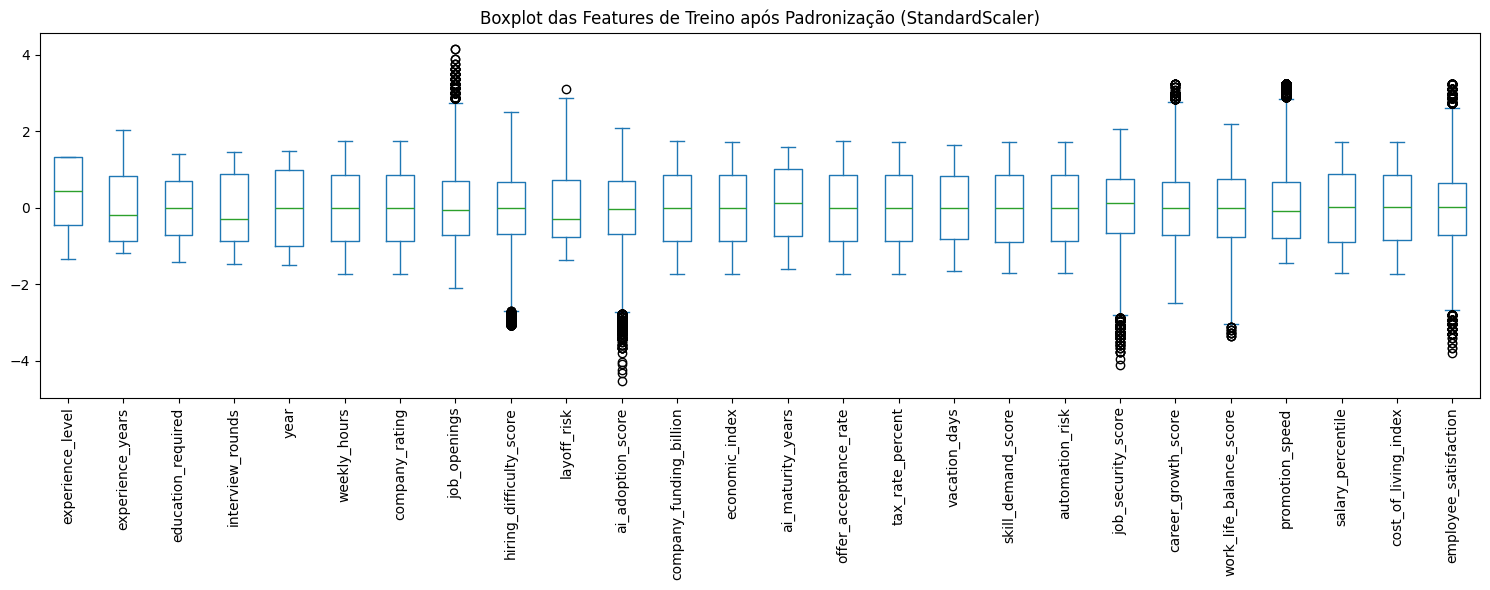

In [137]:
## bloxplot pegando apenas as colunas numéricas com mais de 2 valores únicos

#criando um dataframe temporário para plotar o gráfico baseado no conjunto de dados padronizado.
df_train_scaled = pd.DataFrame(X_train, columns= feature_names)

colunas_para_visualizar = [c for c in df_train_scaled.columns if df_train_scaled[c].nunique() > 2]
df_train_scaled[colunas_para_visualizar].plot(kind='box', figsize=(15, 6))
plt.title("Boxplot das Features de Treino após Padronização (StandardScaler)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Visão Geral do Dataset pós Tratamento dos dados

In [138]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 67 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   experience_level                          90000 non-null  int64  
 1   experience_years                          90000 non-null  int64  
 2   education_required                        90000 non-null  int64  
 3   company_size                              90000 non-null  int64  
 4   interview_rounds                          90000 non-null  int64  
 5   year                                      90000 non-null  int64  
 6   work_mode                                 90000 non-null  int64  
 7   weekly_hours                              90000 non-null  float64
 8   company_rating                            90000 non-null  float64
 9   job_openings                              90000 non-null  int64  
 10  hiring_difficulty_score           

## FASE 2 - CRIAÇÃO, TREINAMENTO E TESTE DO MODELO

Essa fase será dedicada apenas para a criação do modelo da rede neural, utilizando **pytorch**.

### Criação do Modelo: A arquitetura da rede neural

Essa tópico será dedicado a explicar qual é a construção dessa rede neural.

- **Tipos de problemas**

Tendo ciência que na saída da rede ela vai devolver o salário, o modelo de trabalho e o tamanho da companhia, podemos descrever que a solução desse problema será **Multi-task learning** pois serão criadas 3 instâncias do modelo com algumas leves alterações, para lidar com cada um dos problemas dos indicadores: regressão (salário) e classificação (modelo de trabalho e tamanho da companhia) em instâncias diferentes.

---

- **Estrutura da rede**

Construir um único modelo de rede neural para todos os indicadores torna-se inviável para o processo de aprendizagem. Pois estariamos tratando problemas diferentes sob a mesma solução, o que poderia gerar casos de incompatibilidade entre o modelo e o indicador proposta a ser predito.

Ao invés de utilizar o mesmo modelo para os 3 indicadores, foi criado um modelo básico que com algumas alterações, seria instânciados 3 vezes para trabalhar de forma separada e isolada cada um dos indicadores. Dentre as principais alterações que serão feitas para cada instância estão:

1) Variável booleana `is_regression`

A variável booleana que irá determinar se o modelo trata de um problema de regressão ou de classificação por multi-classe. Caso seja este segundo caso, será adicionada uma função `softmax()` para a distribuição das probabilidades das classes preditas.

2) Quantidade de neurônios na camada de saída

A quantidade de neurônios na camada de saída de cada um desses indicadores será diferente:

- salário (regressão): 1 neurônio
- modelo de trabalho (classificação): 3 neurônios (*Onsite, Remote, Hybrid*)
- tamanho da companhia (classificação): 5 neurônios (*Medium, Startup, Enterprise, Small, Large*)

Portanto, a estrutura da camada de saída de cada instância é diferente para cada indicado.

### Criação do Modelo: Importando as Bibliotecas

In [139]:
import torch # pytorch
from torch import nn # importando o módulo principal de nn

### Criação do Modelo: Construindo o Modelo

In [140]:
# O número de entradas irá variar para cada target
n_entradas_sal = X_train_sal.shape[1]
n_entradas_wm  = X_train_wm.shape[1]
n_entradas_co  = X_train_co.shape[1]

n_entradas_sal, n_entradas_wm, n_entradas_co

(6, 25, 12)

In [141]:
class MLPCareer(nn.Module):
    def __init__(self, n_entradas: int, n_saidas: int, is_regression: bool):
        super().__init__()
        self.tronco = nn.Sequential(
            nn.Linear(in_features= n_entradas, out_features= 128),
            nn.ReLU(),
            nn.Dropout(p= 0.1),
            nn.Linear(in_features= 128, out_features= 64),
            nn.ReLU(),
            nn.Dropout(p= 0.1),
            nn.Linear(in_features= 64, out_features= 32),
        )
        if (is_regression is True):
            self.saida = nn.Linear(in_features= 32, out_features= n_saidas)
        else:
            self.saida = nn.Softmax(dim=-1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.saida(self.tronco(x))

# instanciando os modelos de cada indicador
model_salario = MLPCareer(n_entradas= n_entradas_sal, n_saidas= 1, is_regression= True)
model_workmode = MLPCareer(n_entradas= n_entradas_wm, n_saidas= 3, is_regression= False)
model_company = MLPCareer(n_entradas= n_entradas_co, n_saidas= 5, is_regression= False)

print(model_salario)
print(model_workmode)
print(model_company)

MLPCareer(
  (tronco): Sequential(
    (0): Linear(in_features=6, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
  )
  (saida): Linear(in_features=32, out_features=1, bias=True)
)
MLPCareer(
  (tronco): Sequential(
    (0): Linear(in_features=25, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
  )
  (saida): Softmax(dim=-1)
)
MLPCareer(
  (tronco): Sequential(
    (0): Linear(in_features=12, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=

### Criação do Modelo: Preparando os dados para o modelo [Transformando em Tensores]

Quando os dados estão localizados dentro da rede neural, eles precisam ser representados por tensores para que a biblioteca do *pytorch* seja executada. Para isso, será necessário **transformar o conjunto de dados de treinamento em tensores**, tanto os valores da nossa entrada `X` quanto das nossas *labels* `y`.

- OBS1: O "**t**" nas variáveis é de **tensor**.

- OBS2: Durante o processo de *encoding* do conjunto de dados, foi utilizado o `get_dummies()`, criando colunas do tipo booleano. **O pytorch não consegue converter colunas do tipo bool -> tensor**. Por conta disso, preciso converter as colunas *bool* pra *int* e depois em *tensor*.

In [142]:
# transformando os dados em tensores: ndarry (numpy) -> tensor (padrão: float32)
print("- Os dados estavam antes assim: ", type(X_train))

# inputs da rede para salário (feature-selected)
X_train_sal_t = torch.tensor(X_train_sal.astype('float32'), dtype=torch.float32)
X_test_sal_t  = torch.tensor(X_test_sal.astype('float32'),  dtype=torch.float32)

# inputs da rede para work mode (feature-selected)
X_train_wm_t = torch.tensor(X_train_wm.astype('float32'), dtype=torch.float32)
X_test_wm_t  = torch.tensor(X_test_wm.astype('float32'),  dtype=torch.float32)

# inputs da rede para company size (feature-selected)
X_train_co_t = torch.tensor(X_train_co.astype('float32'), dtype=torch.float32)
X_test_co_t  = torch.tensor(X_test_co.astype('float32'),  dtype=torch.float32)

# normalizando a coluna de salário de treino e também a de teste ANTES de converter para tensor!
scaler_salary = StandardScaler()
y_salary_train_scaled = scaler_salary.fit_transform(y_salary_train.values.reshape(-1, 1))
y_salary_test_scaled = scaler_salary.transform(y_salary_test.values.reshape(-1, 1)) #já garantiu a forma [batch, 1]

# salary: é float32 pq é regressão
y_salary_train_t = torch.tensor(y_salary_train_scaled, dtype=torch.float32)
y_salary_test_t  = torch.tensor(y_salary_test_scaled,  dtype=torch.float32)

# workmode e companysize: são longs (ints) porque são classificação
y_workmode_train_t = torch.tensor(y_workmode_train.values, dtype=torch.long)
y_workmode_test_t  = torch.tensor(y_workmode_test.values,  dtype=torch.long)
y_company_train_t = torch.tensor(y_company_train.values, dtype=torch.long)
y_company_test_t  = torch.tensor(y_company_test.values,  dtype=torch.long)

print("\n- Os dados estão convertidos em tensores com salário normalizado!\n")
# type(X_train_sal_t), type(X_test_sal_t), type(y_salary_train_t), type(y_salary_test_t),type(y_workmode_train_t), type(y_workmode_test_t),type(y_company_train_t), type(y_company_test_t)

- Os dados estavam antes assim:  <class 'numpy.ndarray'>

- Os dados estão convertidos em tensores com salário normalizado!



### Criação do Modelo: Utilizando *Dropout*

*Dropout* é uma técnica que oi utilizada nas camadas ocultas da rede, onde ela desativa alguns neurônios das camadas e deixa os pesos da rede menos sensíveis por conta disso.

Trata-se uma técnica aplicada que pode ajudar na generalização do modelo, o que tende a melhorar problemas de *overfitting*, por exemplo.

### Criação do Modelo: Definindo as Funções de Custo

Para cada uma das saídas da rede, haverá um erro relacionado. A questão é que esse erro possui um comportamento diferente em contexto de regressão e de classificação. Por isso, cada uma das saídas terá uma função de custo diferente para representar o seu respectivo erro.

- `loss_salario` (erro do salário): Erro Médio Quadrático, MSE - *Mean Squared Error* (caráter de regressão)
- `loss_workmode` (erro do modo de trabalho): Entropia Cruzada, CrossEntropy (caráter de classificação)
- `loss_company` (erro do tamanho da companhia): Entropia Cruzada, CrossEntropy (caráter de classificação)

In [143]:
loss_fn_salario = nn.L1Loss()
loss_fn_workmode = nn.CrossEntropyLoss()
loss_fn_company = nn.CrossEntropyLoss()

### Criação do Modelo: Definindo o Otimizador

O otimizador será a função responsável por atualizar os pesos.

- Hyperparâmetro da **taxa de aprendizado** pode ser ajustado logo abaixo.

In [144]:
optimizer_salario = torch.optim.Adam(model_salario.parameters(), lr= 0.001)
optimizer_workmode = torch.optim.Adam(model_workmode.parameters(), lr= 0.001)
optimizer_company = torch.optim.Adam(model_company.parameters(), lr= 0.01)

### Treino e Teste do Modelo: Definindo o Loop de Treino + Teste

A parte do **Loop de Treino** seguirá os seguintes passos:

0. Fazer um loop onde os dados serão passados (uma época), ativar o modo treino e dentro dele...
1. Aplicar o algorítmo de *forward propagation* (gerar as predições de treino)
2. Obter o erro, calculando as *loss functions* (comparando as predições com os valores ideias e mensurando o erro de cada saída da rede)
3. *Optimizer Zero Grad* (zerar os gradientes do loop passado, para evitar acúmulos)
4. Aplicar o *back propagation* (calcular os gradientes dos parâmetros)
5. Definir o passo do otimizador (servirá para atualizar os pesos)

A parte **Loop de Teste** seguirá os seguintes passos:

1. Ativar o modo de avaliação (*evaluation*)
2. Realizar o forward propagation (gerar as predições de teste)
3. Salvar em um array as percas de treino e de teste de cada iteração
4. [OPCIONAL] printar um log de progresso

In [145]:
#inicializando arrays que pegarão o histórico de erro para o conjunto de treino e teste

# erro individual por cabeça (treino)
train_losses_sal = []
train_losses_wm = []
train_losses_co = []

# erro individual por cabeça (teste)
test_losses_sal = []
test_losses_wm = []
test_losses_co = []

### Treino e Teste do Modelo: Épocas

In [146]:
epochs = 100

### Treino e Teste do Modelo: Indicador de Salário

In [147]:
# --- [SALÁRIO] LOOP DE TREINAMENTO + TESTE ---
for epoch in range(epochs):
    model_salario.train()
    pred_sal_train = model_salario(X_train_sal_t)

    loss_sal_train = loss_fn_salario(pred_sal_train, y_salary_train_t)

    optimizer_salario.zero_grad()
    loss_sal_train.backward()
    optimizer_salario.step()

    train_losses_sal.append(loss_sal_train.item())

    model_salario.eval()
    with torch.no_grad():
        pred_sal_test = model_salario(X_test_sal_t)

        loss_sal_test = loss_fn_salario(pred_sal_test, y_salary_test_t)

        test_losses_sal.append(loss_sal_test.item())
        if ((epoch % 10 == 0) or (epoch == epochs -1)):
            print(f'============= [ERRO SALÁRIO] Época {epoch:03d} '+'================')
            print(f'Treino: {loss_sal_train.item():.4f} | Teste: {loss_sal_test.item():.4f}')

============= [ERRO SALÁRIO] Época 000 ================
Treino: 0.7969 | Teste: 0.7662
============= [ERRO SALÁRIO] Época 010 ================
Treino: 0.5401 | Teste: 0.4942
============= [ERRO SALÁRIO] Época 020 ================
Treino: 0.3185 | Teste: 0.3035
============= [ERRO SALÁRIO] Época 030 ================
Treino: 0.2991 | Teste: 0.2677
============= [ERRO SALÁRIO] Época 040 ================
Treino: 0.2816 | Teste: 0.2582
============= [ERRO SALÁRIO] Época 050 ================
Treino: 0.2720 | Teste: 0.2487
============= [ERRO SALÁRIO] Época 060 ================
Treino: 0.2691 | Teste: 0.2461
============= [ERRO SALÁRIO] Época 070 ================
Treino: 0.2669 | Teste: 0.2449
============= [ERRO SALÁRIO] Época 080 ================
Treino: 0.2655 | Teste: 0.2437
============= [ERRO SALÁRIO] Época 090 ================
Treino: 0.2633 | Teste: 0.2433
============= [ERRO SALÁRIO] Época 099 ================
Treino: 0.2625 | Teste: 0.2428


In [148]:
# --- [WORK MODE] LOOP DE TREINAMENTO + TESTE ---

for epoch in range(epochs):
    model_workmode.train()
    pred_wm_train = model_workmode(X_train_wm_t)

    loss_wm_train = loss_fn_workmode(pred_wm_train, y_workmode_train_t)

    optimizer_workmode.zero_grad()
    loss_wm_train.backward()
    optimizer_workmode.step()

    train_losses_wm.append(loss_wm_train.item())

    model_workmode.eval()
    with torch.no_grad():
        pred_wm_test = model_workmode(X_test_wm_t)

        loss_wm_test = loss_fn_workmode(pred_wm_test, y_workmode_test_t)

        test_losses_wm.append(loss_wm_test.item())
        if ((epoch % 10 == 0) or (epoch == epochs -1)):
            print(f'============= [ERRO WORKMODE] Época {epoch:03d} '+'================')
            print(f'Treino: {loss_wm_train.item():.4f} | Teste: {loss_wm_test.item():.4f}')

============= [ERRO WORKMODE] Época 000 ================
Treino: 3.4701 | Teste: 3.4690
============= [ERRO WORKMODE] Época 010 ================
Treino: 3.4557 | Teste: 3.4533
============= [ERRO WORKMODE] Época 020 ================
Treino: 3.4076 | Teste: 3.3983
============= [ERRO WORKMODE] Época 030 ================
Treino: 3.2667 | Teste: 3.2502
============= [ERRO WORKMODE] Época 040 ================
Treino: 3.1804 | Teste: 3.1770
============= [ERRO WORKMODE] Época 050 ================
Treino: 3.1710 | Teste: 3.1705
============= [ERRO WORKMODE] Época 060 ================
Treino: 3.1693 | Teste: 3.1693
============= [ERRO WORKMODE] Época 070 ================
Treino: 3.1686 | Teste: 3.1688
============= [ERRO WORKMODE] Época 080 ================
Treino: 3.1684 | Teste: 3.1685
============= [ERRO WORKMODE] Época 090 ================
Treino: 3.1686 | Teste: 3.1685
============= [ERRO WORKMODE] Época 099 ================
Treino: 3.1681 | Teste: 3.1686


In [149]:
# --- [COMPANY] LOOP DE TREINAMENTO + TESTE ---
for epoch in range(epochs):
    model_company.train()
    pred_co_train = model_company(X_train_co_t)

    loss_co_train = loss_fn_company(pred_co_train, y_company_train_t)

    optimizer_company.zero_grad()
    loss_co_train.backward()
    optimizer_company.step()

    train_losses_co.append(loss_co_train.item())

    model_company.eval()
    with torch.no_grad():
        pred_co_test = model_company(X_test_co_t)

        loss_co_test = loss_fn_company(pred_co_test, y_company_test_t)

        test_losses_co.append(loss_co_test.item())
        if ((epoch % 10 == 0) or (epoch == epochs -1)):
            print(f'============= [ERRO COMPANY] Época {epoch:03d} '+'================')
            print(f'Treino: {loss_co_train.item():.4f} | Teste: {loss_co_test.item():.4f}')


============= [ERRO COMPANY] Época 000 ================
Treino: 3.4653 | Teste: 3.4491
============= [ERRO COMPANY] Época 010 ================
Treino: 3.1729 | Teste: 3.1559
============= [ERRO COMPANY] Época 020 ================
Treino: 3.1075 | Teste: 3.0979
============= [ERRO COMPANY] Época 030 ================
Treino: 3.0801 | Teste: 3.0766
============= [ERRO COMPANY] Época 040 ================
Treino: 3.0700 | Teste: 3.0685
============= [ERRO COMPANY] Época 050 ================
Treino: 3.0640 | Teste: 3.0647
============= [ERRO COMPANY] Época 060 ================
Treino: 3.0615 | Teste: 3.0638
============= [ERRO COMPANY] Época 070 ================
Treino: 3.0601 | Teste: 3.0627
============= [ERRO COMPANY] Época 080 ================
Treino: 3.0582 | Teste: 3.0625
============= [ERRO COMPANY] Época 090 ================
Treino: 3.0572 | Teste: 3.0621
============= [ERRO COMPANY] Época 099 ================
Treino: 3.0568 | Teste: 3.0614


### Visualizando as Curvas de Erro: Visão Geral

Plotando as curvas de erros geral e de cada indicador.

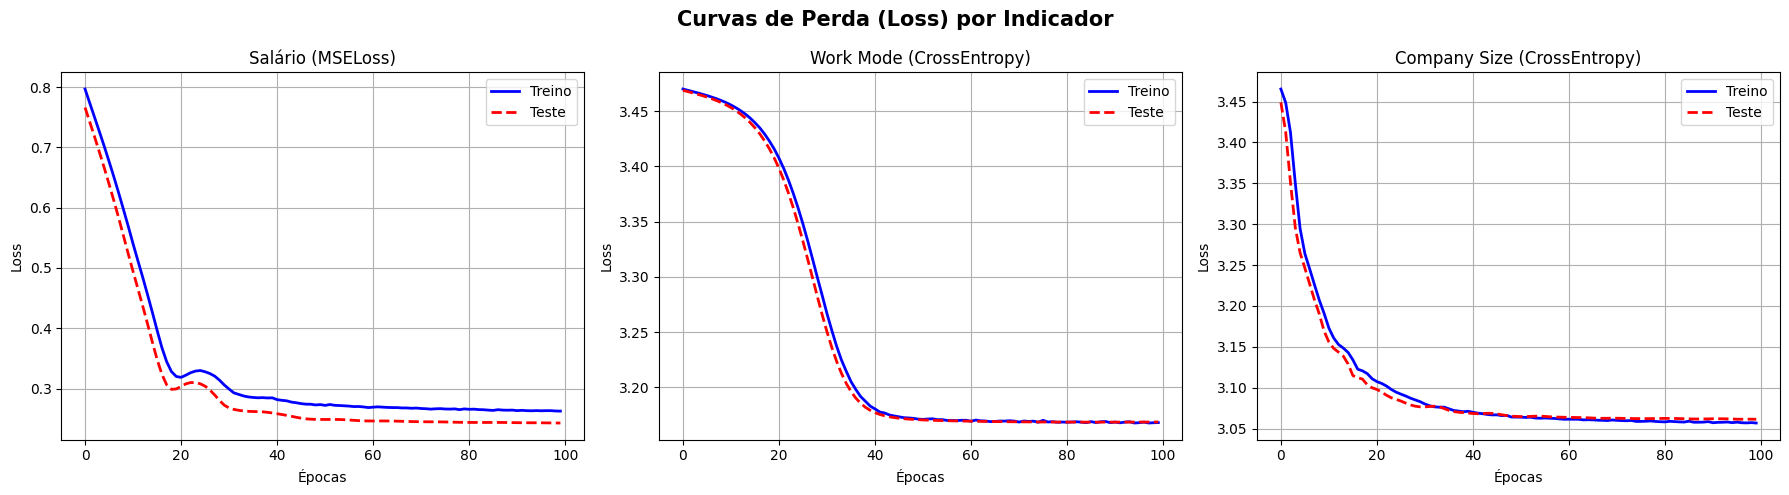

In [150]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Curvas de Perda (Loss) por Indicador', fontsize=15, fontweight='bold')

# Salário
axes[0].plot(range(epochs), train_losses_sal, label='Treino', color='blue', linewidth=2)
axes[0].plot(range(epochs), test_losses_sal,  label='Teste',  color='red',  linewidth=2, linestyle='--')
axes[0].set_title('Salário (MSELoss)')
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Work Mode
axes[1].plot(range(epochs), train_losses_wm, label='Treino', color='blue', linewidth=2)
axes[1].plot(range(epochs), test_losses_wm,  label='Teste',  color='red',  linewidth=2, linestyle='--')
axes[1].set_title('Work Mode (CrossEntropy)')
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

# Company Size
axes[2].plot(range(epochs), train_losses_co, label='Treino', color='blue', linewidth=2)
axes[2].plot(range(epochs), test_losses_co,  label='Teste',  color='red',  linewidth=2, linestyle='--')
axes[2].set_title('Company Size (CrossEntropy)')
axes[2].set_xlabel('Épocas')
axes[2].set_ylabel('Loss')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

### Visualizando as Curvas de Erro: Visualizando o Final das Curvas

Se `epochs`= 50 e `zoom_epochs`=30, ele mostrará da época 20 à 50.

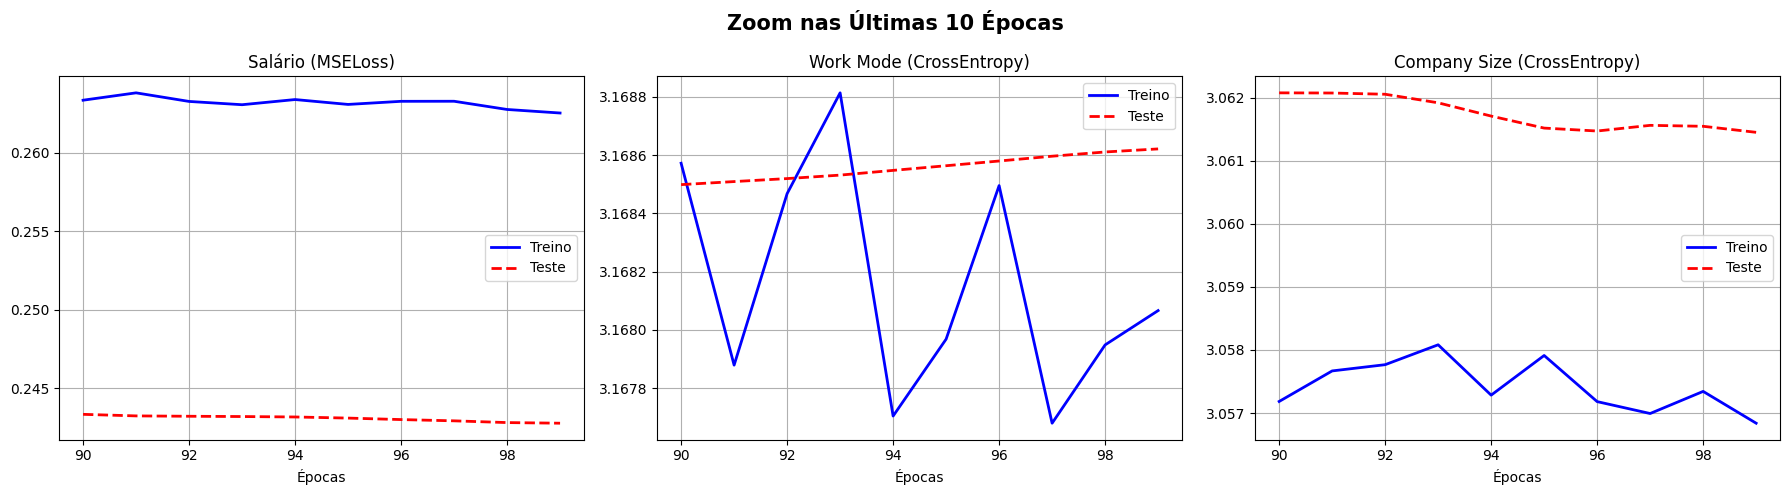

In [151]:
zoom_epochs = 10 #visualizando as últimas 10 épocas
start_epoch = max(0, epochs - zoom_epochs) #começo do zoom das épocas
x_epochs = range(start_epoch, epochs)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Zoom nas Últimas {zoom_epochs} Épocas', fontsize=15, fontweight='bold')

axes[0].plot(x_epochs, train_losses_sal[start_epoch:], label='Treino', color='blue', linewidth=2)
axes[0].plot(x_epochs, test_losses_sal[start_epoch:],  label='Teste',  color='red',  linewidth=2, linestyle='--')
axes[0].set_title('Salário (MSELoss)')
axes[0].set_xlabel('Épocas')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(x_epochs, train_losses_wm[start_epoch:], label='Treino', color='blue', linewidth=2)
axes[1].plot(x_epochs, test_losses_wm[start_epoch:],  label='Teste',  color='red',  linewidth=2, linestyle='--')
axes[1].set_title('Work Mode (CrossEntropy)')
axes[1].set_xlabel('Épocas')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(x_epochs, train_losses_co[start_epoch:], label='Treino', color='blue', linewidth=2)
axes[2].plot(x_epochs, test_losses_co[start_epoch:],  label='Teste',  color='red',  linewidth=2, linestyle='--')
axes[2].set_title('Company Size (CrossEntropy)')
axes[2].set_xlabel('Épocas')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

## FASE 3 - Avaliação do Modelo: Métricas

Nesta seção, avaliaremos o desempenho do modelo utilizando métricas específicas para cada tipo de problema:

- **Salário** (Regressão): MAE e RMSE
- **Modalidade de Trabalho** (Classificação): Acurácia, Precisão, F1-Score e Matriz de Confusão
- **Tamanho da Empresa** (Classificação): Acurácia, Precisão, F1-Score e Matriz de Confusão

Vale mencionar que as predições que saem do nosso modelo estão no formato de tensores (*torch*). Por conta disso, devemos converter esses tensores para matrizes numpy. Dessa forma, o scikit-learn conseguirá entender os nossos dados.

In [152]:
from sklearn.metrics import (mean_absolute_error, root_mean_squared_error,
                             accuracy_score, precision_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)

In [153]:
#Métricas: Salário
model_salario.eval()
with torch.no_grad():
    pred_sal_test = model_salario(X_test_sal_t)

# desfazendo a normalização para voltar à escala real em USD
pred_sal_np = scaler_salary.inverse_transform(pred_sal_test.numpy())
real_sal_np = scaler_salary.inverse_transform(y_salary_test_t.numpy())

mae  = mean_absolute_error(real_sal_np, pred_sal_np)
rmse = root_mean_squared_error(real_sal_np, pred_sal_np)

print('SALÁRIO (real_salary_usd)\n')
print(f'  MAE  : $ {mae:,.2f}')
print(f'  RMSE : $ {rmse:,.2f}')

SALÁRIO (real_salary_usd)

  MAE  : $ 12,188.58
  RMSE : $ 16,180.86


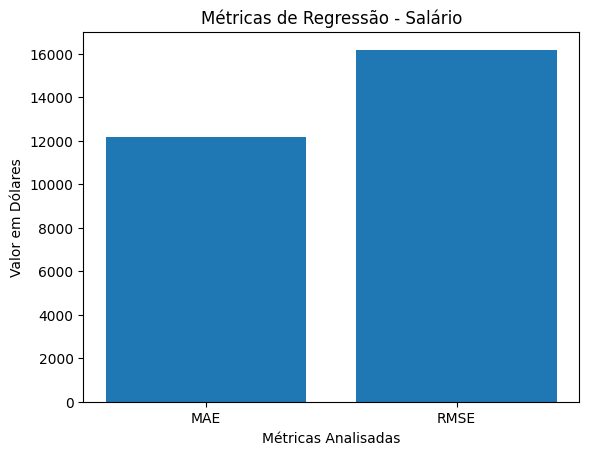

In [154]:
#plotando as métricas de salário

labels = ['MAE', 'RMSE']
values = [mae, rmse]

plt.figure()
plt.bar(labels, values)
plt.title('Métricas de Regressão - Salário')
plt.ylabel('Valor em Dólares')
plt.xlabel('Métricas Analisadas')
plt.grid(False)

plt.savefig('salary_metrics.png')
plt.show()

In [155]:
# Métricas: Work Mode
model_workmode.eval()
with torch.no_grad():
    pred_wm_test = model_workmode(X_test_wm_t)

pred_wm_classes = pred_wm_test.argmax(dim=1).numpy()
real_wm = y_workmode_test_t.numpy()
wm_labels = le.classes_  # ['Hybrid', 'Onsite', 'Remote']

acc_wm = accuracy_score(real_wm, pred_wm_classes)
prec_wm = precision_score(real_wm, pred_wm_classes, average='macro', zero_division=0)
f1_wm = f1_score(real_wm, pred_wm_classes, average='macro', zero_division=0)

print('MODALIDADE DE TRABALHO (work_mode)\n')
print(f'  Acurácia : {acc_wm:.4f}')
print(f'  Precisão : {prec_wm:.4f} (macro)')
print(f'  F1-Score : {f1_wm:.4f} (macro)')
print('\nRelatório detalhado:')
print(classification_report(real_wm, pred_wm_classes, target_names=wm_labels, zero_division=0))

MODALIDADE DE TRABALHO (work_mode)

  Acurácia : 0.3337
  Precisão : 0.3300 (macro)
  F1-Score : 0.2929 (macro)

Relatório detalhado:
              precision    recall  f1-score   support

      Hybrid       0.33      0.13      0.18      5903
      Onsite       0.34      0.67      0.45      6079
      Remote       0.32      0.20      0.25      6018

    accuracy                           0.33     18000
   macro avg       0.33      0.33      0.29     18000
weighted avg       0.33      0.33      0.29     18000



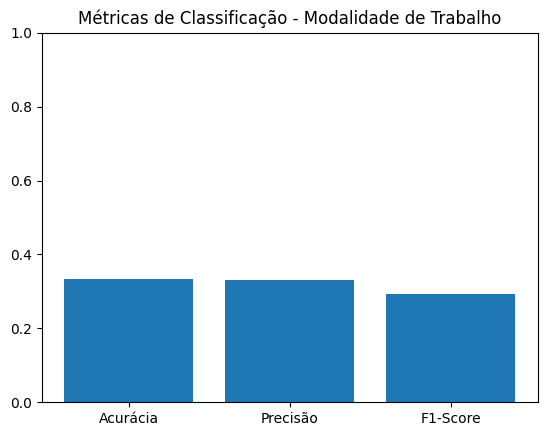

In [156]:
# plotando as métricas work mode
labels = ['Acurácia', 'Precisão', 'F1-Score']
values = [acc_wm, prec_wm, f1_wm]

plt.figure()
plt.bar(labels, values)
plt.title('Métricas de Classificação - Modalidade de Trabalho')
plt.ylim(0,1)
plt.grid(False)

plt.savefig('workmode_metrics.png')
plt.show()

In [157]:
# Métricas: Company Size
model_company.eval()
with torch.no_grad():
    pred_co_test = model_company(X_test_co_t)

pred_co_classes = pred_co_test.argmax(dim=1).numpy()
real_co = y_company_test_t.numpy()
co_labels = ['Startup', 'Small', 'Medium', 'Large', 'Enterprise']

acc_co = accuracy_score(real_co, pred_co_classes)
prec_co = precision_score(real_co, pred_co_classes, average='macro', zero_division=0)
f1_co = f1_score(real_co, pred_co_classes, average='macro', zero_division=0)

print('TAMANHO DA EMPRESA (company_size)\n')
print(f'  Acurácia : {acc_co:.4f}')
print(f'  Precisão : {prec_co:.4f} (macro)')
print(f'  F1-Score : {f1_co:.4f} (macro)')
print('\nRelatório detalhado:')
print(classification_report(real_co, pred_co_classes, target_names=co_labels, zero_division=0))

TAMANHO DA EMPRESA (company_size)

  Acurácia : 0.4539
  Precisão : 0.3575 (macro)
  F1-Score : 0.3962 (macro)

Relatório detalhado:
              precision    recall  f1-score   support

     Startup       0.76      0.91      0.83      3607
       Small       0.27      0.24      0.25      3462
      Medium       0.29      0.40      0.34      3652
       Large       0.00      0.00      0.00      3595
  Enterprise       0.47      0.70      0.56      3684

    accuracy                           0.45     18000
   macro avg       0.36      0.45      0.40     18000
weighted avg       0.36      0.45      0.40     18000



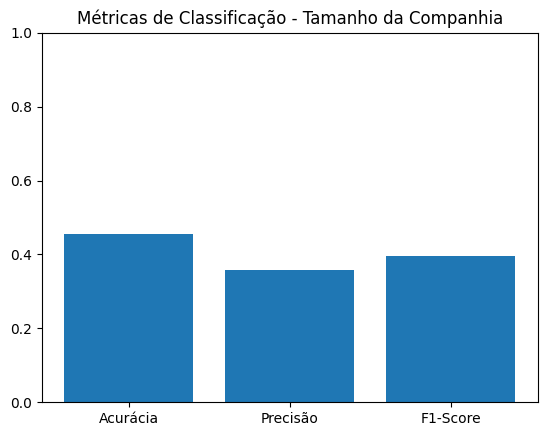

In [158]:
# plotando as métricas de
labels = ['Acurácia', 'Precisão', 'F1-Score']
values = [acc_co, prec_co, f1_co]

plt.figure()
plt.bar(labels, values)
plt.title('Métricas de Classificação - Tamanho da Companhia')
plt.ylim(0,1)
plt.grid(False)

plt.savefig('companysize_metrics.png')
plt.show()

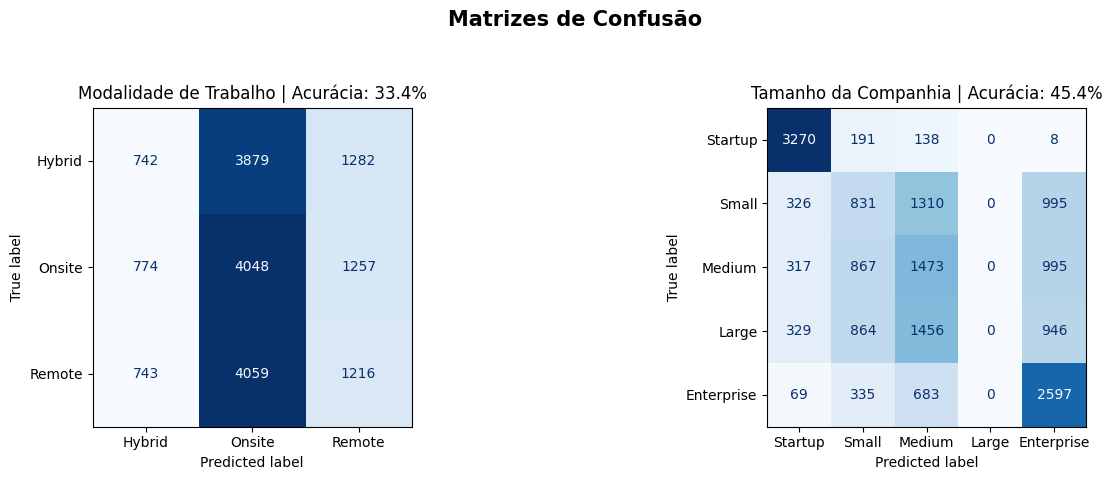

In [159]:
# Métricas: Matrizes de Confusão
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Matrizes de Confusão', fontsize=15, fontweight='bold')

cm_wm = confusion_matrix(real_wm, pred_wm_classes)
ConfusionMatrixDisplay(cm_wm, display_labels=wm_labels).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Modalidade de Trabalho | Acurácia: {acc_wm*100:.1f}%')

cm_co = confusion_matrix(real_co, pred_co_classes)
ConfusionMatrixDisplay(cm_co, display_labels=co_labels).plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title(f'Tamanho da Companhia | Acurácia: {acc_co*100:.1f}%')

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()

<Figure size 700x500 with 0 Axes>

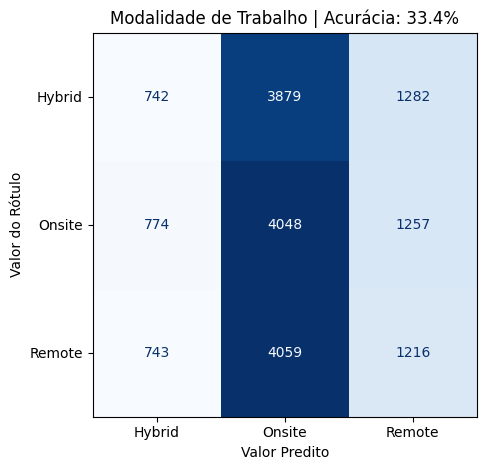

<Figure size 700x500 with 0 Axes>

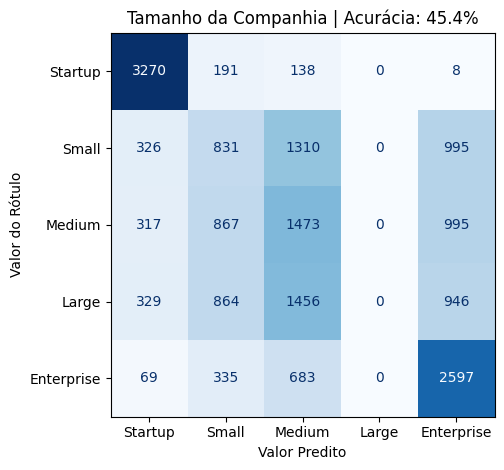

In [160]:
# Métricas: Matrizes de Confusão
plt.figure(figsize=(7, 5))

cm_wm = confusion_matrix(real_wm, pred_wm_classes)
ConfusionMatrixDisplay(cm_wm, display_labels=wm_labels).plot(
    cmap='Blues',
    colorbar=False
)

plt.title(f'Modalidade de Trabalho | Acurácia: {acc_wm*100:.1f}%')
plt.xlabel('Valor Predito')
plt.ylabel('Valor do Rótulo')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))

cm_co = confusion_matrix(real_co, pred_co_classes)
ConfusionMatrixDisplay(cm_co, display_labels=co_labels).plot(
    cmap='Blues',
    colorbar=False
)

plt.title(f'Tamanho da Companhia | Acurácia: {acc_co*100:.1f}%')
plt.xlabel('Valor Predito')
plt.ylabel('Valor do Rótulo')
plt.tight_layout()
plt.show()

In [161]:
from IPython.display import display
import pandas as pd

# tabela de métricas do work mode
tabela_wm = pd.DataFrame({
    'Métrica':  ['Acurácia', 'Precisão (macro)', 'F1-Score (macro)'],
    'Valor':    [acc_wm, prec_wm, f1_wm]
})
tabela_wm['Valor'] = tabela_wm['Valor'].map('{:.4f}'.format)
tabela_wm.index = tabela_wm.index + 1  # índice começa em 1

print('MODALIDADE DE TRABALHO (work_mode)\n')
display(tabela_wm)
print('\nRelatório detalhado:')
print(classification_report(real_wm, pred_wm_classes, target_names=wm_labels, zero_division=0))

MODALIDADE DE TRABALHO (work_mode)



,Métrica,Valor
1,Acurácia,0.3337
2,Precisão (macro),0.3300
3,F1-Score (macro),0.2929



Relatório detalhado:
              precision    recall  f1-score   support

      Hybrid       0.33      0.13      0.18      5903
      Onsite       0.34      0.67      0.45      6079
      Remote       0.32      0.20      0.25      6018

    accuracy                           0.33     18000
   macro avg       0.33      0.33      0.29     18000
weighted avg       0.33      0.33      0.29     18000



In [162]:
# tabela de métricas do company size
tabela_co = pd.DataFrame({
    'Métrica':  ['Acurácia', 'Precisão (macro)', 'F1-Score (macro)'],
    'Valor':    [acc_co, prec_co, f1_co]
})
tabela_co['Valor'] = tabela_co['Valor'].map('{:.4f}'.format)
tabela_co.index = tabela_co.index + 1

print('TAMANHO DA EMPRESA (company_size)\n')
display(tabela_co)
print('\nRelatório detalhado:')
print(classification_report(real_co, pred_co_classes, target_names=co_labels, zero_division=0))

TAMANHO DA EMPRESA (company_size)



,Métrica,Valor
1,Acurácia,0.4539
2,Precisão (macro),0.3575
3,F1-Score (macro),0.3962



Relatório detalhado:
              precision    recall  f1-score   support

     Startup       0.76      0.91      0.83      3607
       Small       0.27      0.24      0.25      3462
      Medium       0.29      0.40      0.34      3652
       Large       0.00      0.00      0.00      3595
  Enterprise       0.47      0.70      0.56      3684

    accuracy                           0.45     18000
   macro avg       0.36      0.45      0.40     18000
weighted avg       0.36      0.45      0.40     18000



#### Imagens a serem plotadas no artigo

In [163]:
#import pandas as pd
#import matplotlib.pyplot as plt
#import matplotlib.dates as mdates

# carregando os dados
#df = pd.read_csv('data.csv')

#df['ref_date'] = pd.to_datetime(df['ref_date'], format='%Y%m')

# removendo espaços em branco extras que podem vir no CSV
#df.columns = df.columns.str.strip()

#Dicionário de Tradução
#traducoes = {
#    'Brazil': 'Brasil',
#    'United States': 'Estados Unidos',
#    'United Kingdom': 'Reino Unido',
#    'Germany': 'Alemanha',
#    'Hong Kong (China)': 'Hong Kong (China)',
#    'Canada': 'Canadá',
#    'Portugal': 'Portugal',
#    'Korea': 'Coreia do Sul',
#    'India': 'Índia'
#}

# setup do plot
#plt.figure(figsize=(10, 7), facecolor='white')
#ax = plt.gca()

# filtrando países que não irão no plot
#countries_to_exclude = ['Canada', 'Korea', 'Germany']
#paises_filtrados = [p for p in traducoes.keys() if p not in countries_to_exclude]

#cores = ['#348abd', '#467821', '#a60628', '#cf4457', '#7a68a6', '#db843d', '#188487', '#e24a33', '#8e8e8e']

#for i, pais_english in enumerate(paises_filtrados):
    # verificando se o nome do país em inglês existe na coluna do dataframe
    #if pais_english in df['Country_label'].unique():
        # Filter dataframe for the current country (using its English name) and sort by date for correct plotting
        #df_pais = df[df['Country_label'] == pais_english].sort_values('ref_date')
        # Filter data to start from 2023-01
        #df_pais = df_pais[df_pais['ref_date'] >= pd.to_datetime('2023-01', format='%Y-%m')]
        #plt.plot(df_pais['ref_date'], df_pais['Relative_AI_hiring_index_pct'], marker='o', markersize=4,
                 #label=traducoes[pais_english], color=cores[i % len(cores)], linewidth=1.5)
    #else:
        #print(f"Aviso: Dados para o país '{traducoes[pais_english]}' não encontrados no CSV!")

# estilização dos Eixos
#plt.ylabel('Índice de contratação relativo (%)', fontsize=12, color='black')

# Formatação de Datas
#ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
# Definindo um intervalo para não embolar (ex: a cada 6 meses)
#ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))

#plt.xticks(rotation=45, color='black', fontsize=12)
#plt.yticks(color='black', fontsize=12)

#ax.spines['top'].set_visible(False)
#ax.spines['right'].set_visible(False)
#ax.spines['left'].set_color('#dddddd')
#ax.spines['bottom'].set_color('#dddddd')

#plt.grid(axis='y', linestyle='--', alpha=0.7, color='#eeeeee')

# legendas do gráfico
#plt.legend(loc='upper left',
           #ncol=1, frameon=False, fontsize=12, handletextpad=0.5)

#plt.tight_layout()
#plt.show()

### IA Explicável (XIA): *SHAP VALUES*

Agora será o momento para visualizar a importância de cada uma das *featuras* para a predição realizada deste modelo.

In [164]:
import shap
import numpy as np
import matplotlib.pyplot as plt
import torch

# SHAP precisa que o modelo receba numpy e devolva numpy
# Por isso criamos funes "wrapper" para cada modelo
# (o SHAP no fala diretamente com PyTorch)

def predict_salario(X_np):
    """
    Wrapper do model_salario para o SHAP.
    responsável por receber um numpy array e devolver numpy array com a predição de salario.
    .squeeze() serve pra remover a dimensão extra [batch, 1] > [batch]
    """
    tensor = torch.tensor(X_np, dtype=torch.float32)
    with torch.no_grad():
        saida = model_salario(tensor)
    return saida.flatten().numpy()

def predict_workmode(X_np):
    """
    Wrapper do model_workmode para o SHAP.
    responsável por devolver as probabilidades das 3 classes (Hybrid, Onsite, Remote).
    """
    tensor = torch.tensor(X_np, dtype=torch.float32)
    with torch.no_grad():
        saida = model_workmode(tensor)
    return saida.numpy()

def predict_company(X_np):
    """
    Wrapper do model_company para o SHAP.
    responsável por devolver as probabilidades das 5 classes (Startup, Small, Medium, Large, Enterprise).
    """
    tensor = torch.tensor(X_np, dtype=torch.float32)
    with torch.no_grad():
        saida = model_company(tensor)
    return saida.numpy()

print("Funes wrapper criadas!")

Funes wrapper criadas!


In [165]:
# calculando os shap values para cada modelo

print("Calculando SHAP para Salário...")
background_sal = shap.sample(X_train_sal, 100)
explainer_sal  = shap.KernelExplainer(predict_salario, background_sal)
# Explicando 200 amostras do conjunto de teste
shap_sal = explainer_sal.shap_values(X_test_sal[:200], nsamples=100)
print("  ✓ Salário concluído!")

print("Calculando SHAP para Work Mode...")
background_wm = shap.sample(X_train_wm, 100)
explainer_wm  = shap.KernelExplainer(predict_workmode, background_wm)
# Para classificação, shap_values retorna uma LISTA com um array por classe
shap_wm = explainer_wm.shap_values(X_test_wm[:200], nsamples=100)
print("  ✓ Work Mode concluído!")

print("Calculando SHAP para Company Size...")
background_co = shap.sample(X_train_co, 100)
explainer_co  = shap.KernelExplainer(predict_company, background_co)
shap_co = explainer_co.shap_values(X_test_co[:200], nsamples=100)
print("  ✓ Company Size concluído!")

print("\nTodos os SHAP values calculados!")

Calculando SHAP para Salário...


  0%|          | 0/200 [00:00<?, ?it/s]

  ✓ Salário concluído!
Calculando SHAP para Work Mode...


  0%|          | 0/200 [00:00<?, ?it/s]

  ✓ Work Mode concluído!
Calculando SHAP para Company Size...


  0%|          | 0/200 [00:00<?, ?it/s]

  ✓ Company Size concluído!

Todos os SHAP values calculados!


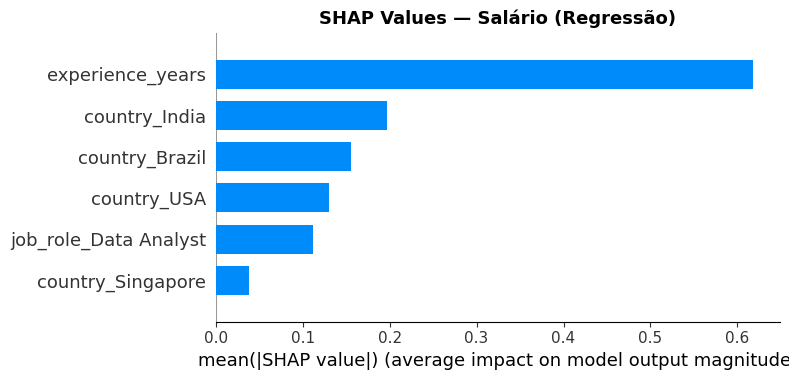

Salvo: shap_salario.png


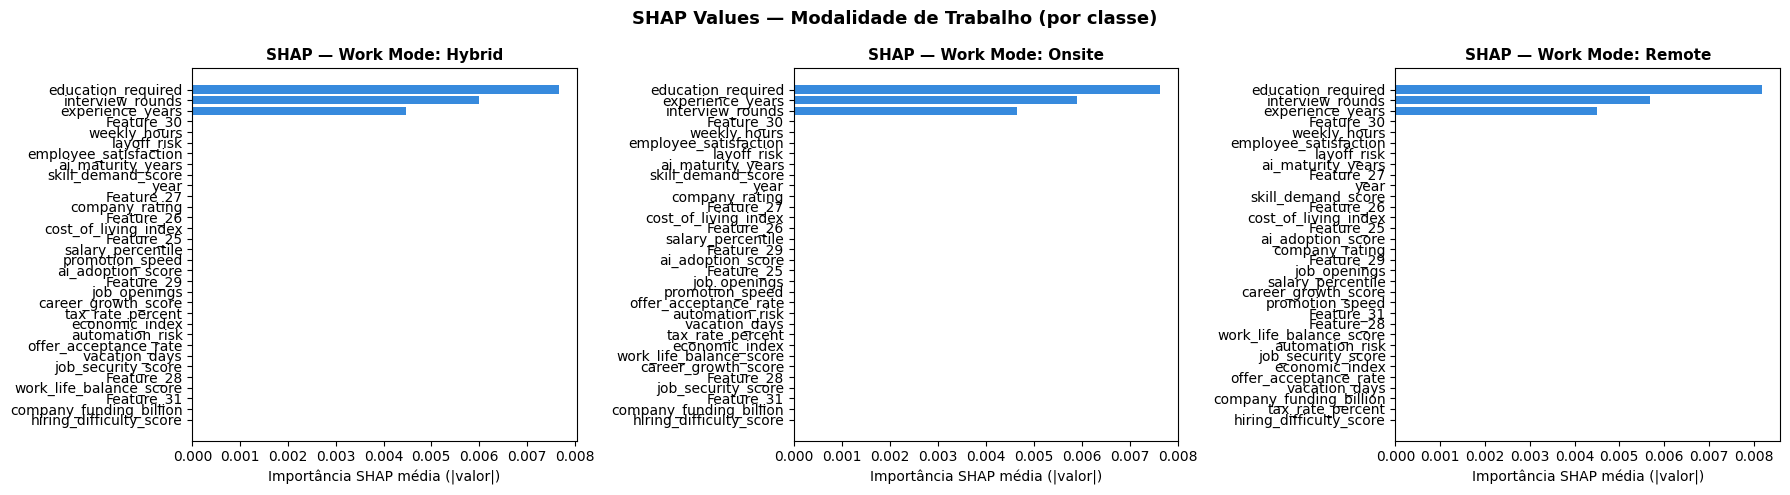

Salvo: shap_workmode.png


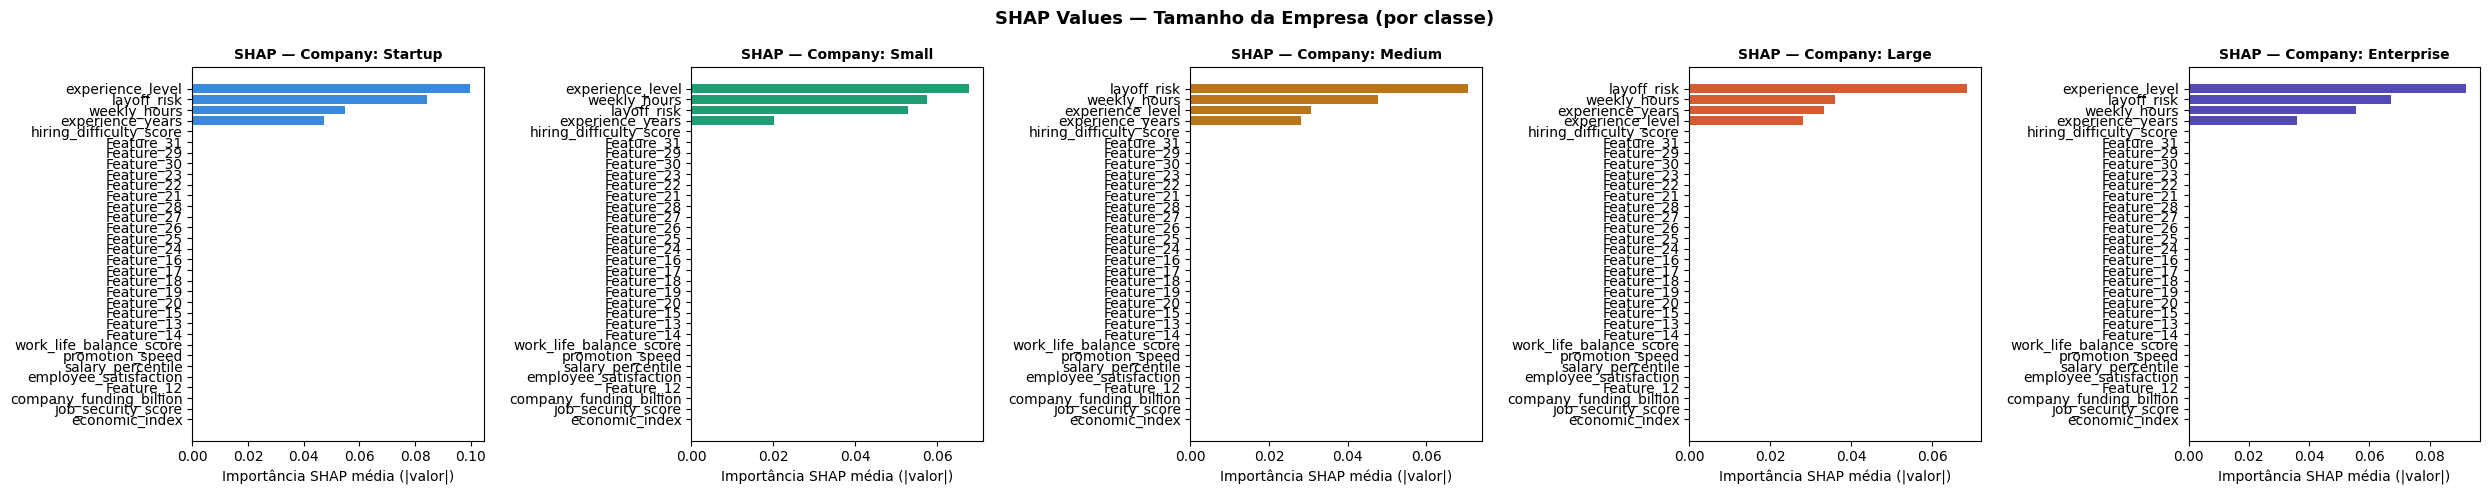

Salvo: shap_company.png


In [166]:
# gráficos SHAP dos 3 indicadores

#nomes das features de cada modelo
nomes_sal = features_sal   # lista dos features de salário
nomes_wm  = features_wm    # lista dos features de work mode
nomes_co  = features_co    # lista dos features de company size

# salvando os rótulos das classes de classificação
labels_wm = ['Hybrid', 'Onsite', 'Remote']
labels_co = ['Startup', 'Small', 'Medium', 'Large', 'Enterprise']


if len(nomes_wm) < np.abs(shap_wm[0]).shape[1]:
    num_missing_features = np.abs(shap_wm[0]).shape[1] - len(nomes_wm)
    nomes_wm_padded = nomes_wm + [f'Feature_{i}' for i in range(len(nomes_wm), np.abs(shap_wm[0]).shape[1])]
    print(f"Warning: nomes_wm was padded from {len(nomes_wm)} to {len(nomes_wm_padded)} features to match SHAP output.")
    nomes_wm = nomes_wm_padded

# gráfico de salário
# plottando em um Bar plot para mostrar importância média absoluta de cada feature, mostrando quais features mais influenciaram as predições de salário
plt.figure(figsize=(8, 4))
shap.summary_plot(
    shap_sal,
    X_test_sal[:200],
    feature_names=nomes_sal,
    plot_type="bar",      # barras horizontais com importância média
    show=False
)
plt.title("SHAP Values — Salário (Regressão)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("shap_salario.png", dpi=150, bbox_inches='tight')
plt.show()
print("Salvo: shap_salario.png")


# gráfico de work mode
fig, eixos = plt.subplots(1, 3, figsize=(18, 5))

for i, (label, ax) in enumerate(zip(labels_wm, eixos)):
    #calculando importância média absoluta de cada feature para esta classe
    imp_media = np.abs(shap_wm[i]).mean(axis=0)
    ordem = np.argsort(imp_media)[::-1]  # ordenando da maior para menor

    ax.barh(
        [nomes_wm[j] for j in ordem],
        imp_media[ordem],
        color='#378ADD'
    )
    ax.set_title(f"SHAP — Work Mode: {label}", fontsize=11, fontweight='bold')
    ax.set_xlabel("Importância SHAP média (|valor|)")
    ax.invert_yaxis()  # feature mais importante sempre no topo

plt.suptitle("SHAP Values — Modalidade de Trabalho (por classe)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("shap_workmode.png", dpi=150, bbox_inches='tight')
plt.show()
print("Salvo: shap_workmode.png")


# gráfico de company size
if len(nomes_co) < np.abs(shap_co[0]).shape[1]:
    num_missing_features = np.abs(shap_co[0]).shape[1] - len(nomes_co)
    nomes_co_padded = nomes_co + [f'Feature_{i}' for i in range(len(nomes_co), np.abs(shap_co[0]).shape[1])]
    print(f"Warning: nomes_co was padded from {len(nomes_co)} to {len(nomes_co_padded)} features to match SHAP output.")
    nomes_co = nomes_co_padded

fig, eixos = plt.subplots(1, 5, figsize=(25, 5))

cores = ['#378ADD', '#1D9E75', '#BA7517', '#D85A30', '#534AB7']

for i, (label, ax, cor) in enumerate(zip(labels_co, eixos, cores)):
    imp_media = np.abs(shap_co[i]).mean(axis=0)
    ordem = np.argsort(imp_media)[::-1]

    ax.barh(
        [nomes_co[j] for j in ordem],
        imp_media[ordem],
        color=cor
    )
    ax.set_title(f"SHAP — Company: {label}", fontsize=10, fontweight='bold')
    ax.set_xlabel("Importância SHAP média (|valor|)")
    ax.invert_yaxis()

plt.suptitle("SHAP Values — Tamanho da Empresa (por classe)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("shap_company.png", dpi=150, bbox_inches='tight')
plt.show()
print("Salvo: shap_company.png")

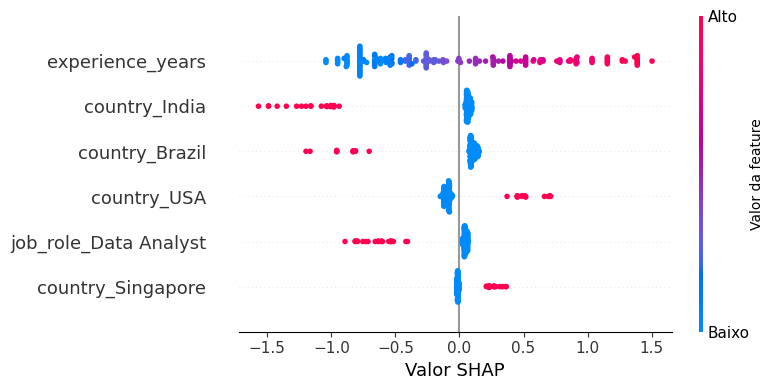

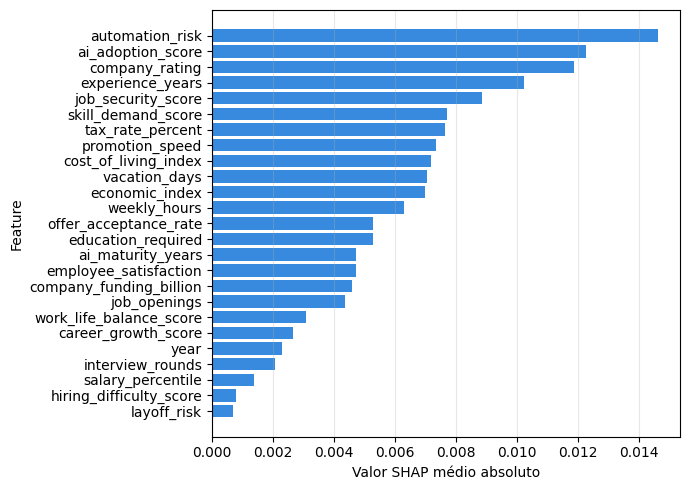

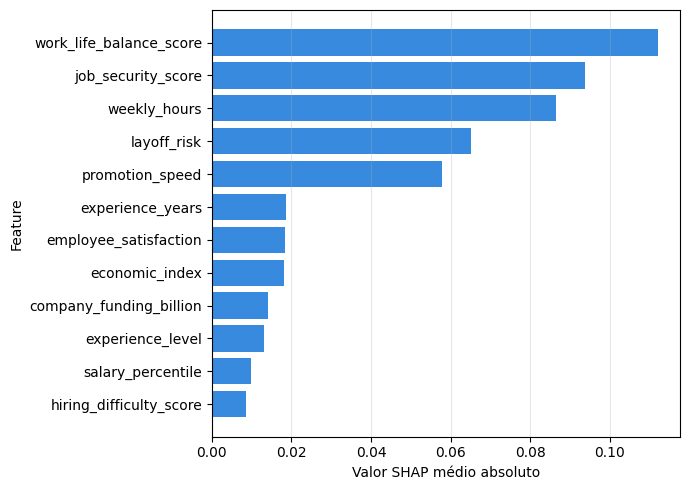

In [167]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# plotando o indicador de salário em um beeswarm plot
fig, ax = plt.subplots(figsize=(8, 4))
shap.summary_plot(
    shap_sal[:, :len(features_sal)],
    X_test_sal[:200],
    feature_names=features_sal,
    show=False,
    plot_size=None
)
ax = plt.gca()
ax.set_xlabel("Valor SHAP")

# traduz o colorbar
cb = plt.gcf().axes[-1]  # o colorbar é o último eixo da figura
cb.set_ylabel("Valor da feature", fontsize=10)
cb.set_yticks([0, 1])
cb.set_yticklabels(['Baixo', 'Alto'])

plt.tight_layout()
plt.savefig("shap_salario.png", dpi=150, bbox_inches='tight')
plt.show()


# o gráfico para a modalidade de trabalho bar plot agregado (todas as classes juntas)
# indicará a immportância média absoluta por feature, somada entre as 3 classes
imp_wm = np.abs(shap_wm[:, :, :3]).mean(axis=(0, 2))  # shape (25,)
ordem_wm = np.argsort(imp_wm)  # crescente para barh ficar com maior no topo

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(
    [features_wm[j] for j in ordem_wm],
    imp_wm[ordem_wm],
    color='#378ADD'
)
ax.set_xlabel("Valor SHAP médio absoluto")
ax.set_ylabel("Feature")
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig("shap_workmode.png", dpi=150, bbox_inches='tight')
plt.show()


# o gráfico para tamamnho da companhia será também bar plot agregado
imp_co = np.abs(shap_co[:, :, :5]).mean(axis=(0, 2))  # shape (9,)
ordem_co = np.argsort(imp_co)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(
    [features_co[j] for j in ordem_co],
    imp_co[ordem_co],
    color='#378ADD'
)
ax.set_xlabel("Valor SHAP médio absoluto")
ax.set_ylabel("Feature")
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig("shap_company.png", dpi=150, bbox_inches='tight')
plt.show()

In [168]:
# printando o shape dos valores
print("=== SHAPES DOS SHAP VALUES ===")
print(f"type(shap_sal)    : {type(shap_sal)}")
print(f"type(shap_wm)     : {type(shap_wm)}")
print(f"type(shap_co)     : {type(shap_co)}")

print(f"\nshap_sal shape    : {np.array(shap_sal).shape}")

print(f"\nshap_wm type      : {type(shap_wm)}")
if isinstance(shap_wm, list):
    print(f"  n_classes       : {len(shap_wm)}")
    for i, v in enumerate(shap_wm):
        print(f"  shap_wm[{i}] shape: {np.array(v).shape}")
else:
    print(f"  shape           : {np.array(shap_wm).shape}")

print(f"\nshap_co type      : {type(shap_co)}")
if isinstance(shap_co, list):
    print(f"  n_classes       : {len(shap_co)}")
    for i, v in enumerate(shap_co):
        print(f"  shap_co[{i}] shape: {np.array(v).shape}")
else:
    print(f"  shape           : {np.array(shap_co).shape}")

print(f"\nX_test_wm[:200] shape : {X_test_wm[:200].shape}")
print(f"X_test_co[:200] shape : {X_test_co[:200].shape}")

=== SHAPES DOS SHAP VALUES ===
type(shap_sal)    : <class 'numpy.ndarray'>
type(shap_wm)     : <class 'numpy.ndarray'>
type(shap_co)     : <class 'numpy.ndarray'>

shap_sal shape    : (200, 6)

shap_wm type      : <class 'numpy.ndarray'>
  shape           : (200, 25, 32)

shap_co type      : <class 'numpy.ndarray'>
  shape           : (200, 12, 32)

X_test_wm[:200] shape : (200, 25)
X_test_co[:200] shape : (200, 12)


## A análise dos resultados será encontrada no artigo: **Predição de Vagas de Empregos no Mercado de IA e Dados Utilizando Redes Neurais Artificiais**, que está disponível no link logo abaixo:

https://periodicos.ufersa.edu.br/index.php/ecop/article/view/15400